# Analyse SL-CR Experiment Results

Notebook for inspecting the merged ECLYPSE metric output, separating timeout and non-timeout events, and plotting the main Prolog reasoning metrics by topology.

## Setup

The input file is expected to be the merged parquet produced from the experiment logs. Change `RESULTS_PATH` if the file lives elsewhere.

In [20]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RESULTS_PATH = Path(".") / "results.parquet"
PLOTS_PATH = Path(".") / "plots"
GRID_PLOTS_PATH = PLOTS_PATH / "grid"
HEATMAP_PLOTS_PATH = PLOTS_PATH / "heatmap"
SCATTERPLOT_PLOTS_PATH = PLOTS_PATH / "scatterplot"

FIG_FORMAT = "pdf"
FIG_DPI = 600

METRICS = [
    "prolog_query_seconds",
    "placement_migrations",
]

METRIC_LABELS = {
    "prolog_query_seconds": "Execution time [s]",
    "prolog_inferences": "Prolog inferences",
    "placement_migrations": "Migrations",
}

COL_LABELS = {
    "nodes": "Infrastructure size",
    "components": "Components",
}

EVENT_COLS = [
    # "event_id",
    "n_event",
    "callback_id",
    "value",
    "mode",
    "nodes",
    "components",
    "seed",
    "topology",
]

## Load and inspect

In [21]:
df = pd.read_parquet(RESULTS_PATH, columns=EVENT_COLS)

MODES = list(df["mode"].unique())
NODES = list(df["nodes"].unique())
COMPONENTS = list(df["components"].unique())
TOPOLOGIES = list(df["topology"].unique())

print(f"rows: {len(df)}")
print(f"columns: {list(df.columns)}")

rows: 300000
columns: ['n_event', 'callback_id', 'value', 'mode', 'nodes', 'components', 'seed', 'topology']


Split into two dataframes: one for timeout events, and one for non-timeout events. The timeout events are those where `callback_id` is `query_timeout` and `value` is 1. The non-timeout events are all the others.

In [22]:
group_cols = ["mode", "nodes", "components", "seed", "topology", "n_event"]

mask_timeout_row = (
    (df["callback_id"] == "query_timeout") &
    (df["value"] == 1)
)

timeout_groups = df.loc[mask_timeout_row, group_cols].drop_duplicates()

df_marked = df.merge(
    timeout_groups.assign(has_timeout=True),
    on=group_cols,
    how="left"
)

df_marked["has_timeout"] = df_marked["has_timeout"].fillna(False).astype(bool)

df_timeout = df_marked[df_marked["has_timeout"]].drop(columns="has_timeout")
df_no_timeout = df_marked[~df_marked["has_timeout"]].drop(columns="has_timeout")

df_plot = df_no_timeout.copy()
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=["value"])

In [23]:
event_cols = ["mode", "nodes", "components", "seed", "topology", "n_event"]

events_marked = (
    df_marked[event_cols + ["has_timeout"]]
    .drop_duplicates()
)

timeout_by_topology = (
    events_marked
    .groupby("topology", as_index=False)
    .agg(
        total_events=("has_timeout", "size"),
        timeout_events=("has_timeout", "sum"),
    )
)

timeout_by_topology["timeout_percentage"] = (
    100 * timeout_by_topology["timeout_events"] / timeout_by_topology["total_events"]
)

display(timeout_by_topology)

,topology,total_events,timeout_events,timeout_percentage
0,BA,20000,1051,5.255
1,ER,20000,1016,5.080
2,IAG,20000,1051,5.255


## FILTERS

In [24]:
NODES_FILTER = [500,750,1000]
COMPONENTS_FILTER = [50,100,200,300,400]
MODE_FILTER = None
TOPOLOGY_FILTER = None
N_EVENT_FILTER = 2


def apply_filters(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    if N_EVENT_FILTER is not None:
        out = out[out["n_event"] >= N_EVENT_FILTER]
    if NODES_FILTER is not None:
        out = out[out["nodes"].isin(NODES_FILTER)]
    if COMPONENTS_FILTER is not None:
        out = out[out["components"].isin(COMPONENTS_FILTER)]
    if MODE_FILTER is not None:
        out = out[out["mode"].isin(MODE_FILTER)]
    if TOPOLOGY_FILTER is not None:
        out = out[out["topology"].isin(TOPOLOGY_FILTER)]
    return out

print(f"rows before filters: {len(df_plot)}")
plot_df = apply_filters(df_plot)
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")

print(f"rows after filters: {len(plot_df)}")

rows before filters: 243585
rows after filters: 190508


In [25]:
def remove_outliers_iqr(group, col="value", k=1.5):
    q1 = group[col].quantile(0.25)
    q3 = group[col].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0 or pd.isna(iqr):
        return group

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return group[
        (group[col] >= lower) &
        (group[col] <= upper)
    ]

def remove_outliers_zscore(group, col="value", threshold=3):
    std = group[col].std()

    if std == 0 or pd.isna(std):
        return group

    z = (group[col] - group[col].mean()) / std

    return group[np.abs(z) < threshold]


## RELPLOT

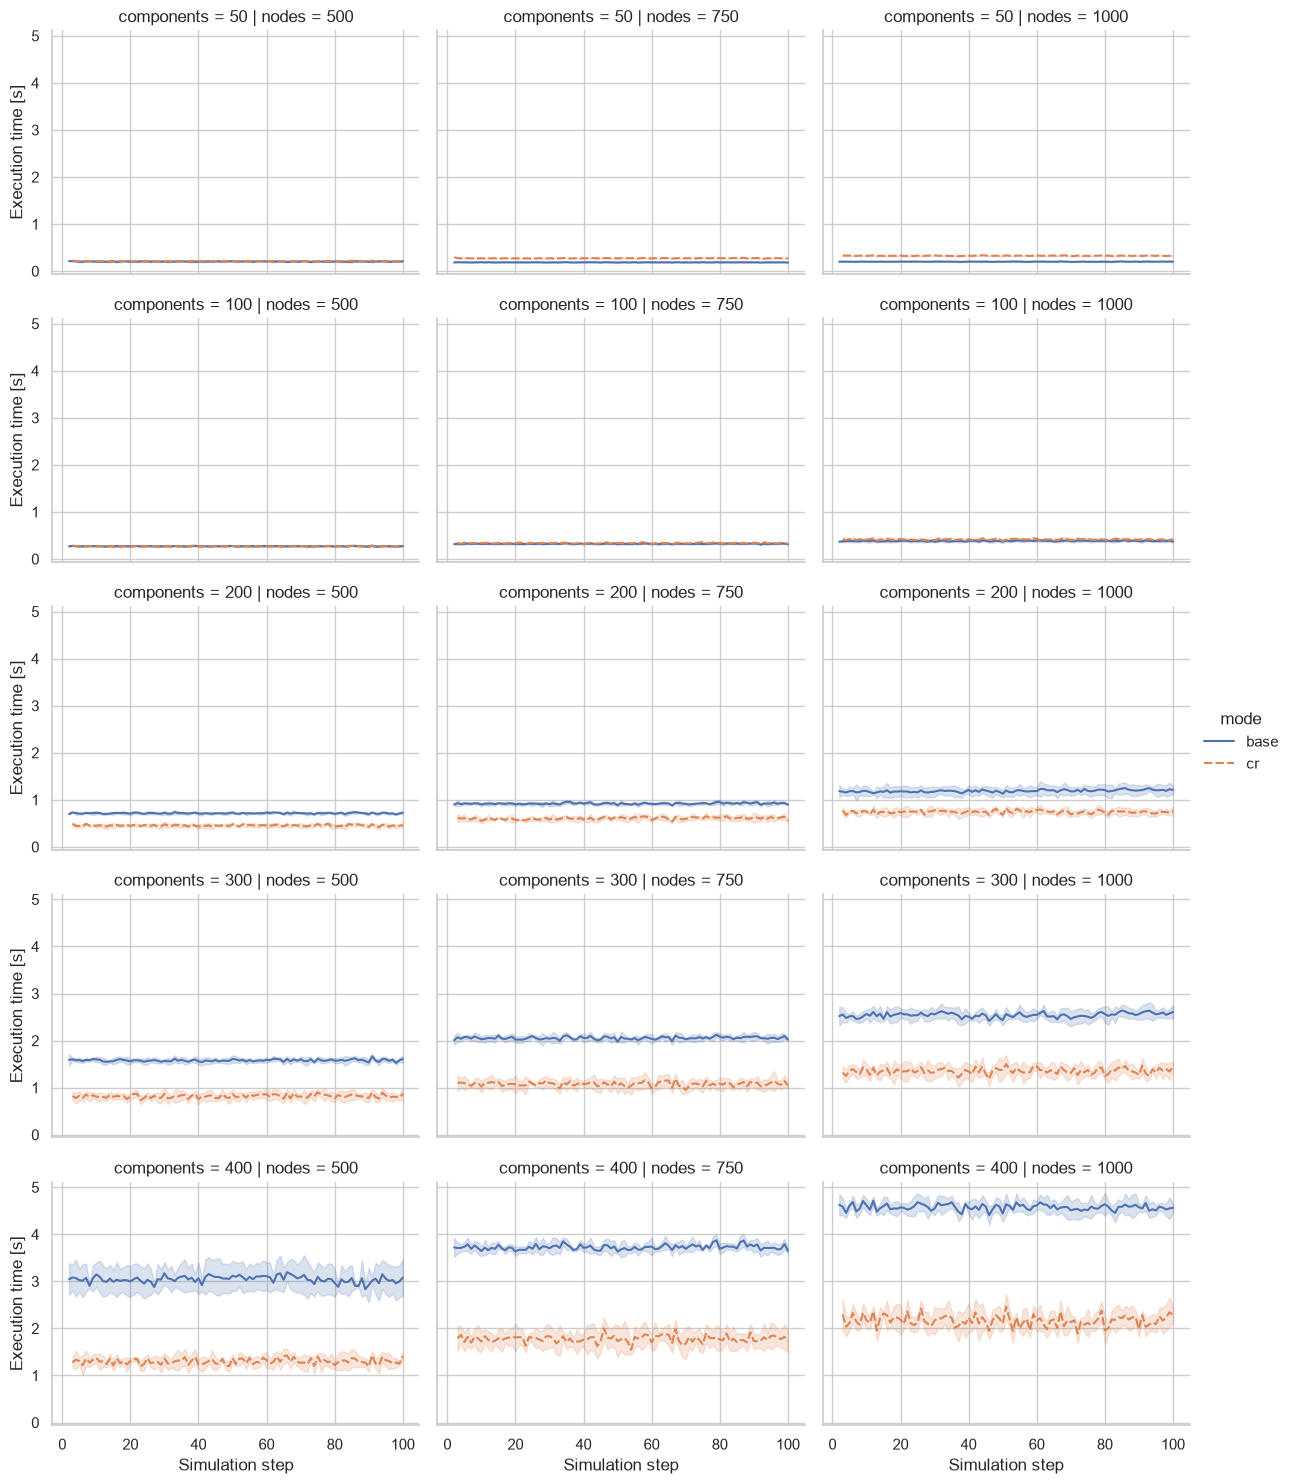

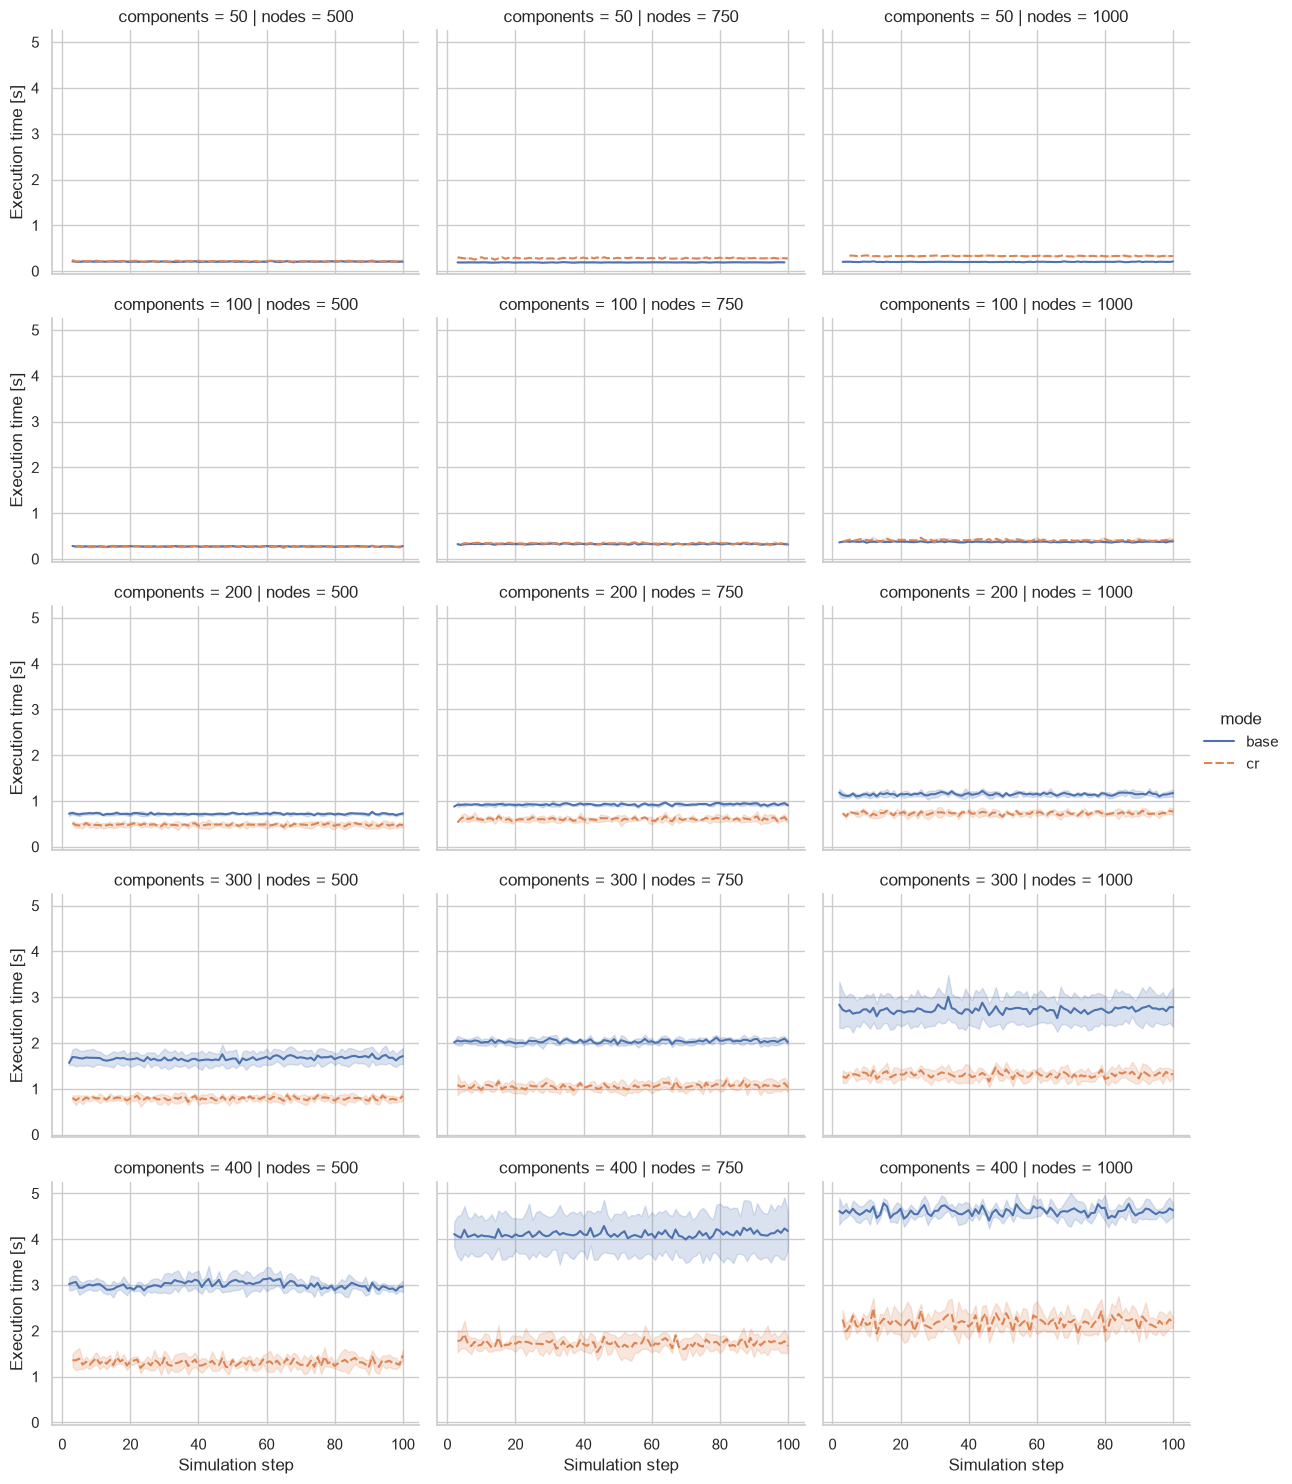

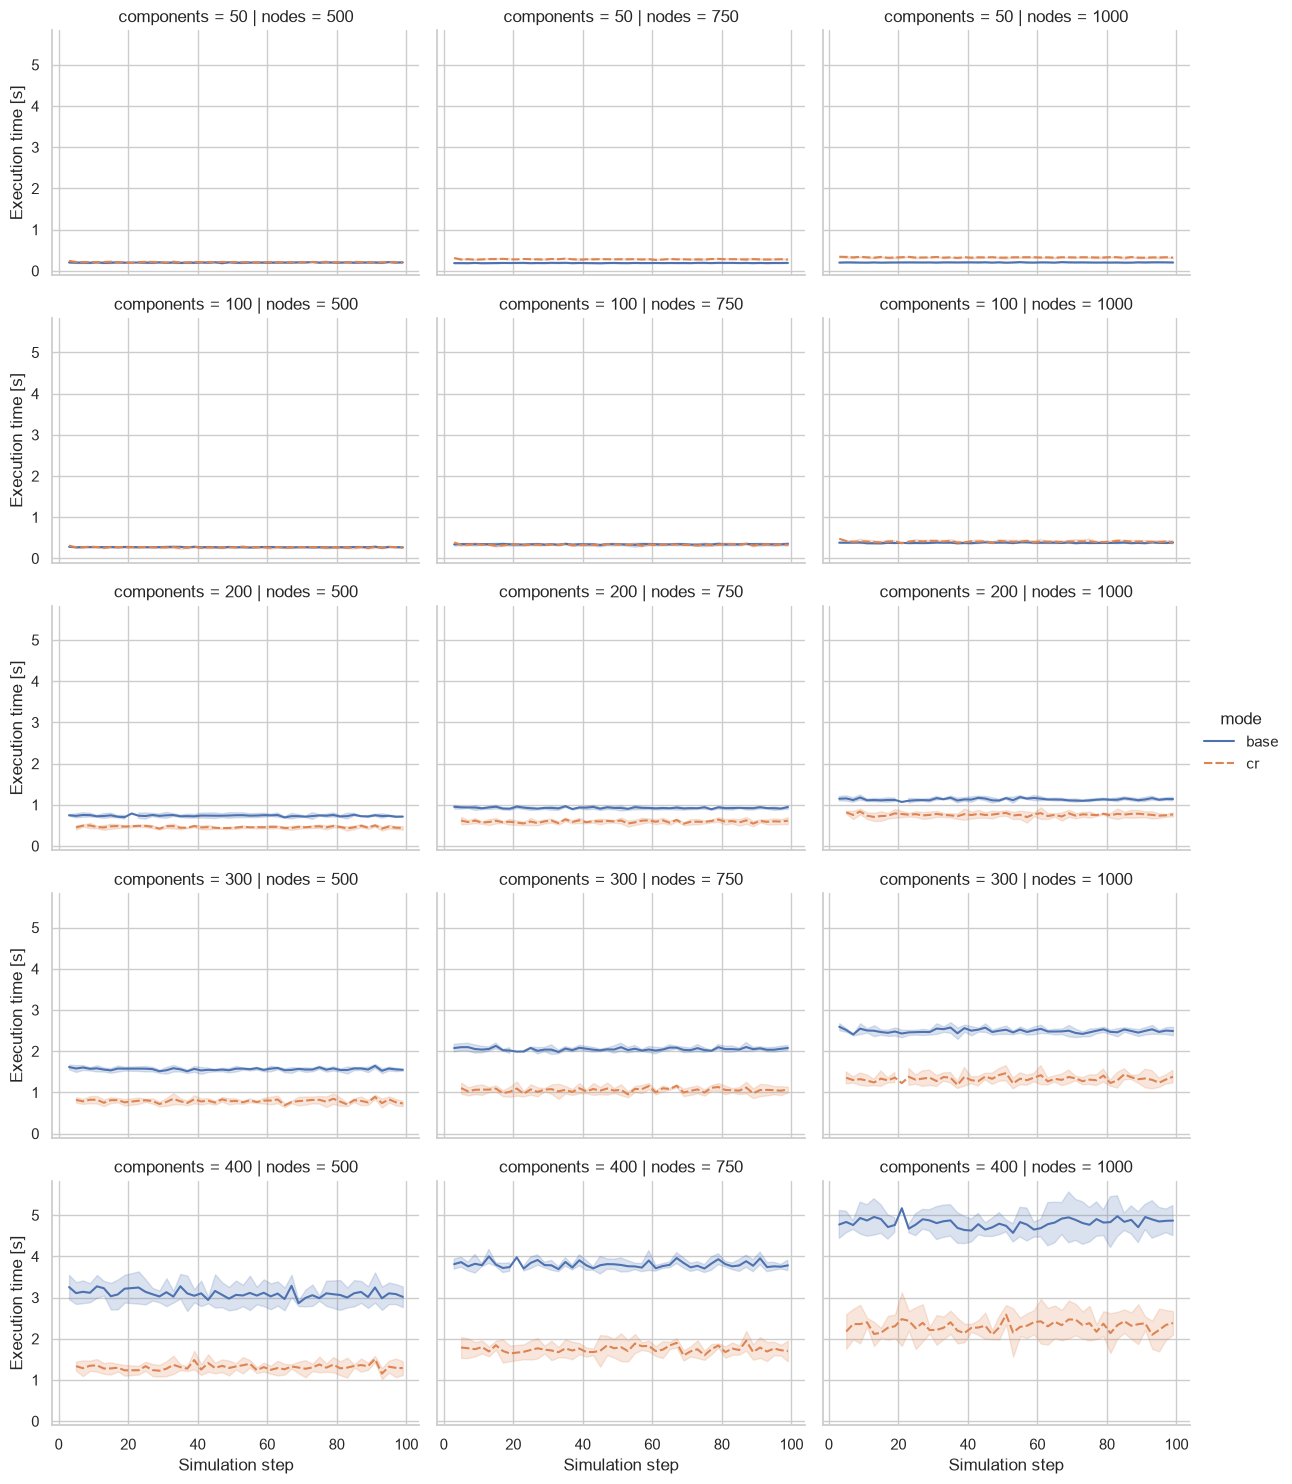

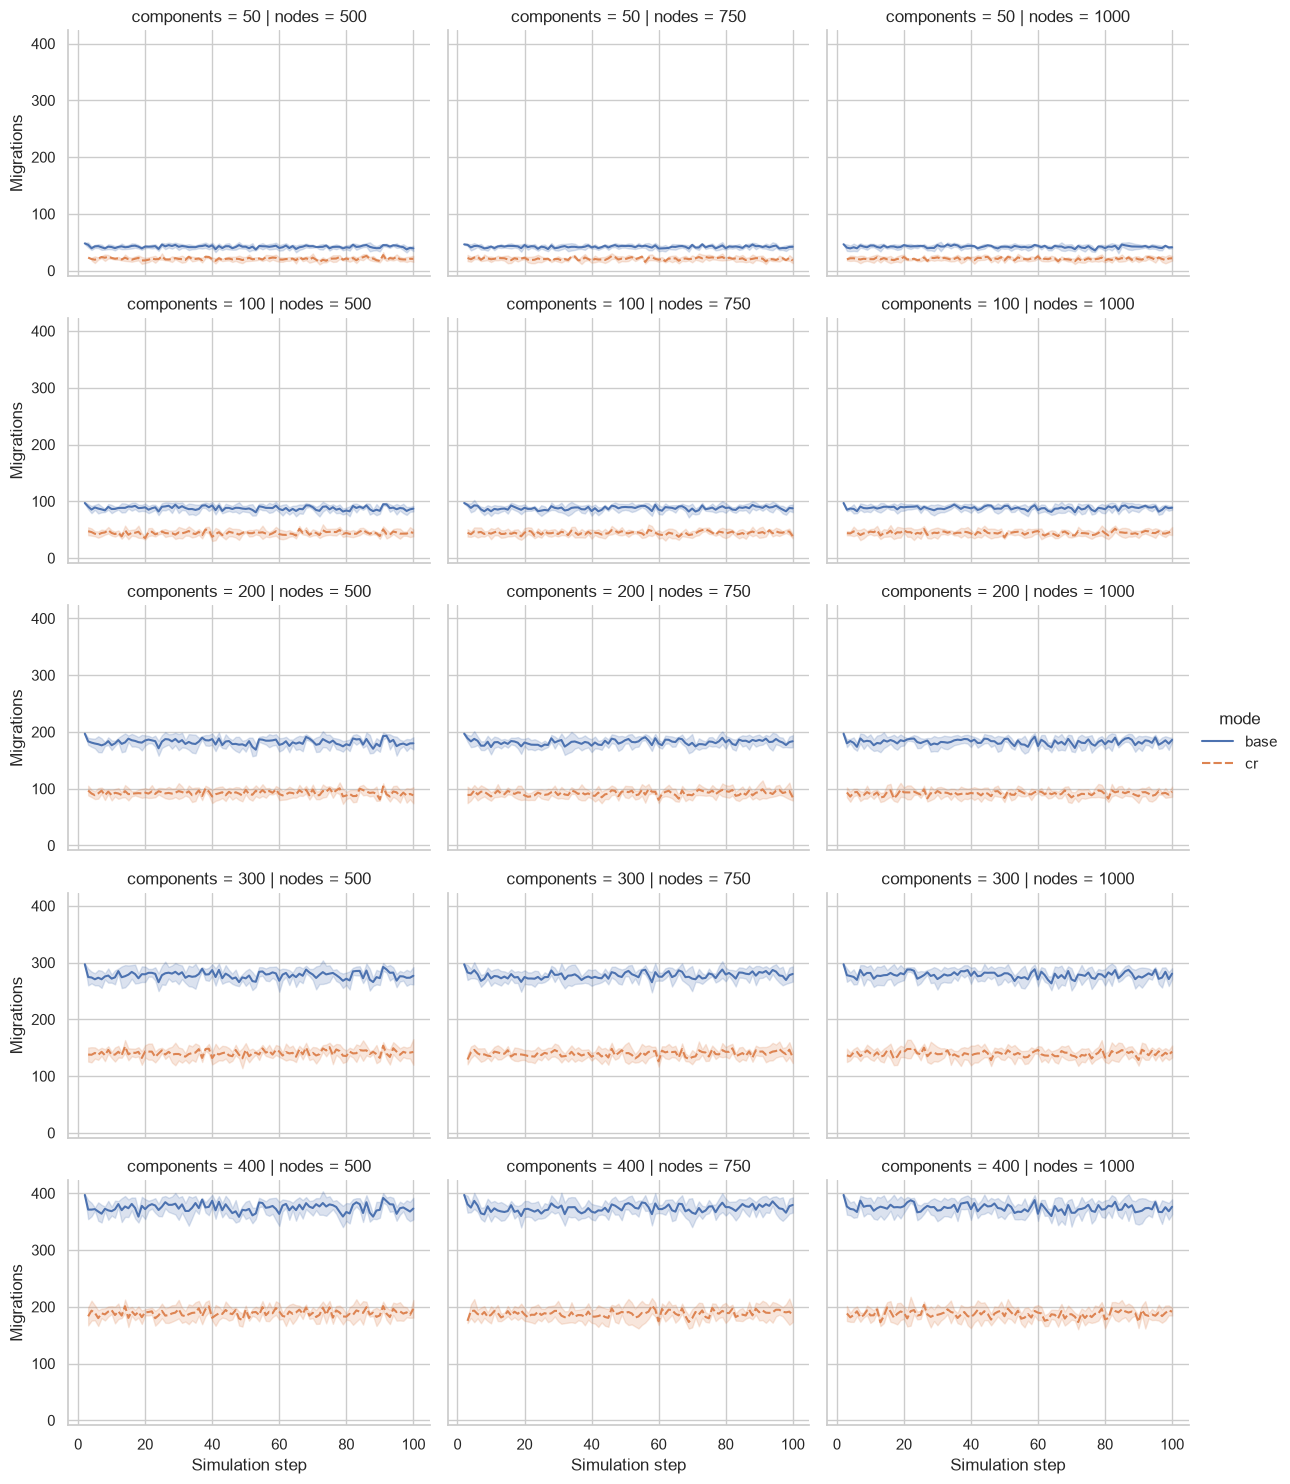

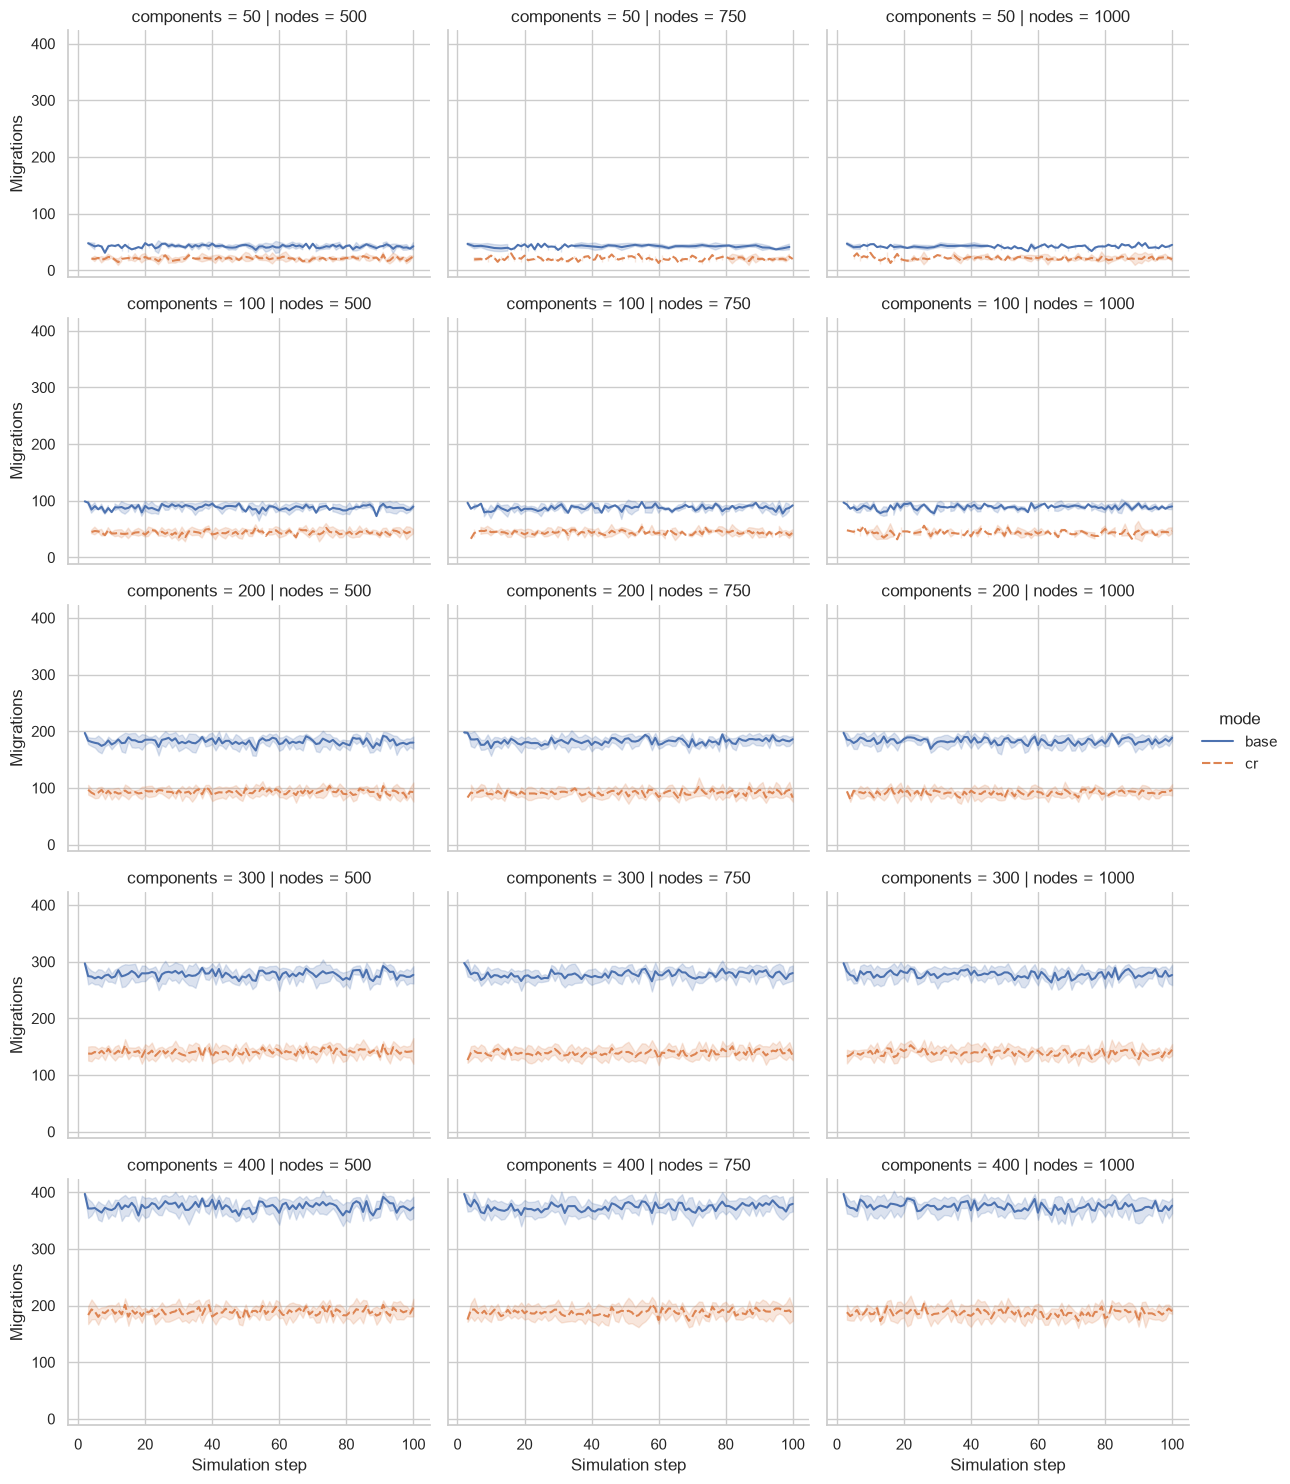

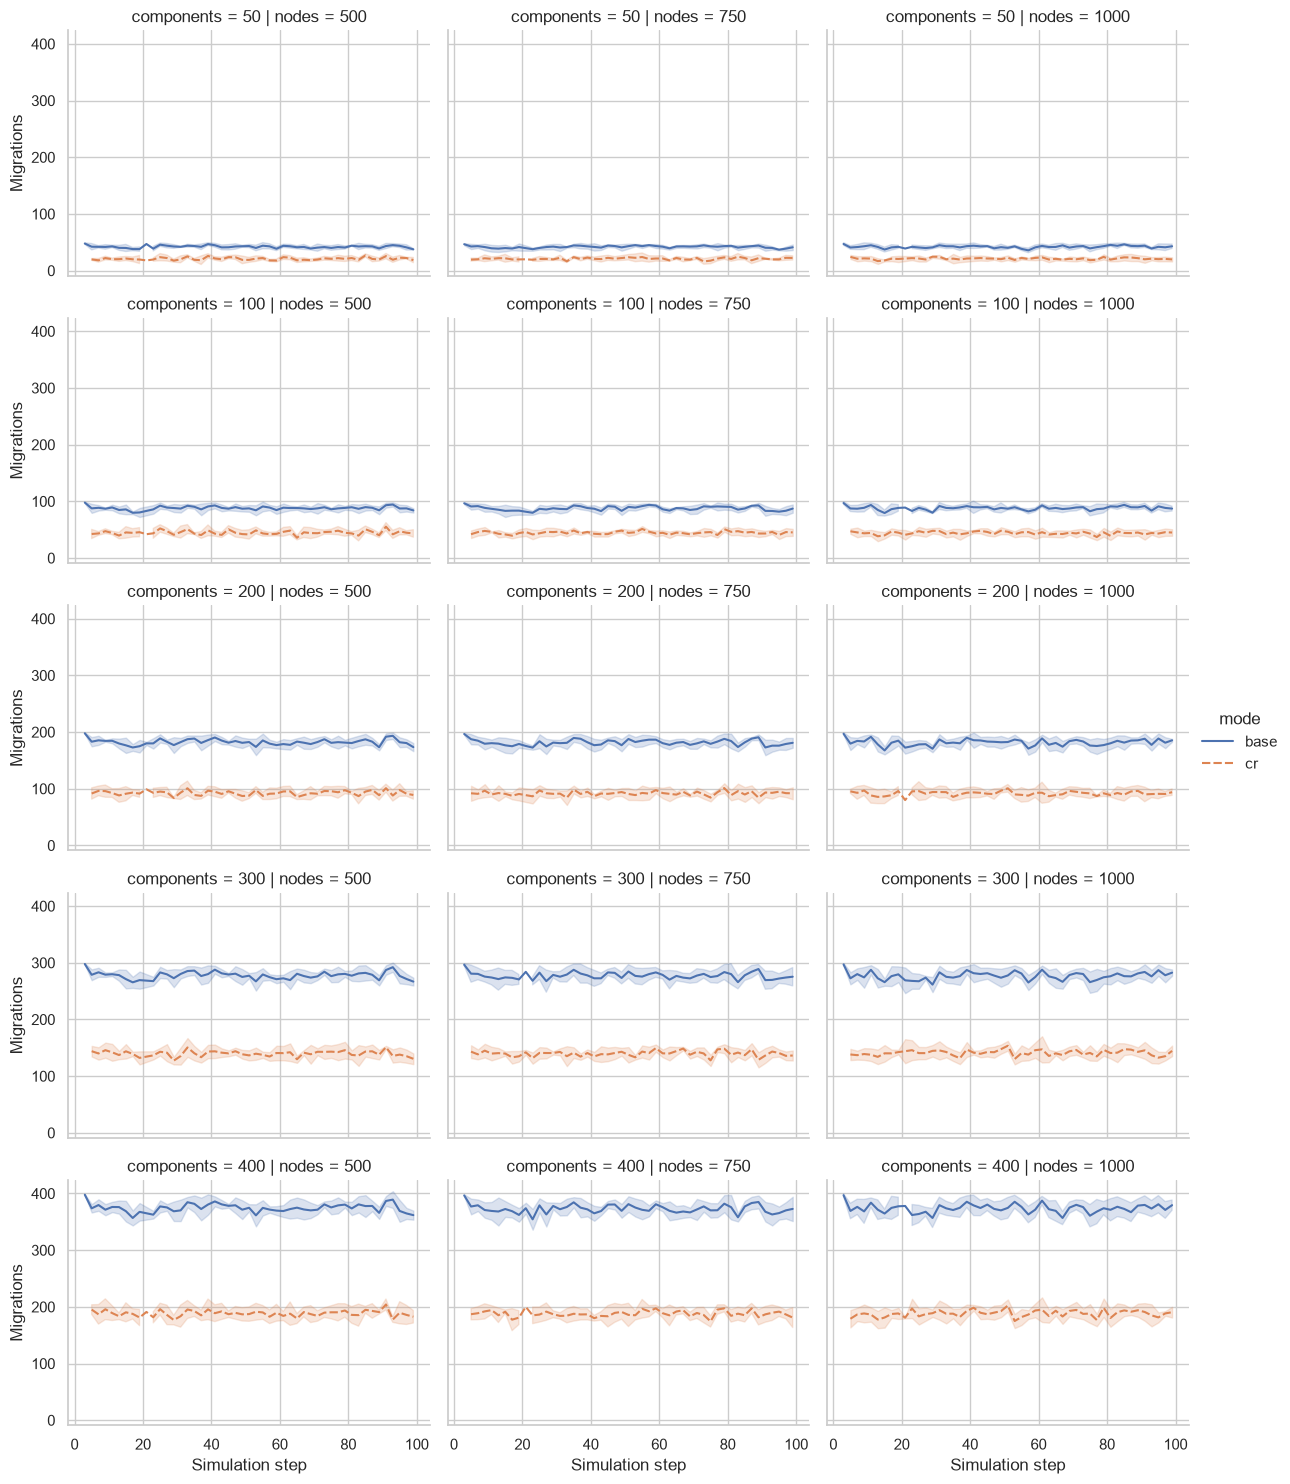

In [26]:
outlier_group_cols = ["mode", "nodes", "components"]

for metric in METRICS:
    for topology in TOPOLOGIES:

        data = plot_df[
            (plot_df["callback_id"] == metric) &
            (plot_df["topology"] == topology)
        ].copy()

        data = data.groupby(outlier_group_cols).apply(remove_outliers_iqr).copy()

        if data.empty:
            print(f"{metric} - {topology}: no data after outlier removal")
            continue

        g = sns.relplot(
            data=data,
            x="n_event",
            y="value",
            hue="mode",
            style="mode",
            col="nodes",
            row="components",
            kind="line",
            errorbar="sd",
            marker=None,
            height=3.0,
            aspect=1.35,
            facet_kws={"sharex": True, "sharey": True},
        )

        g.set_axis_labels("Simulation step", METRIC_LABELS[metric])
        g.set_titles(
            row_template="components = {row_name}",
            col_template="nodes = {col_name}"
        )

        # g.figure.suptitle(
        #     f"{METRIC_LABELS[metric]} - {topology}",
        #     y=1.03,
        #     fontsize=14
        # )

        for ax in g.axes.flat:
            ax.grid(True)

        fig_path = GRID_PLOTS_PATH / metric / topology
        fig_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_path.with_suffix(f".{FIG_FORMAT}"), dpi=FIG_DPI, format=FIG_FORMAT)
        plt.show()

## HEATMAP

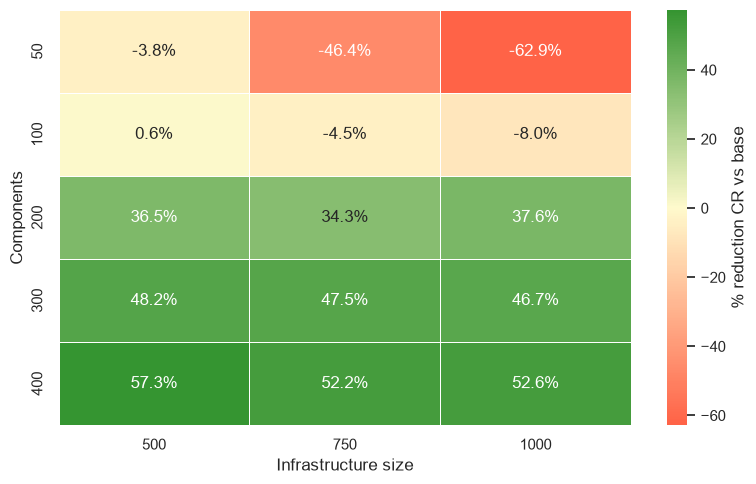

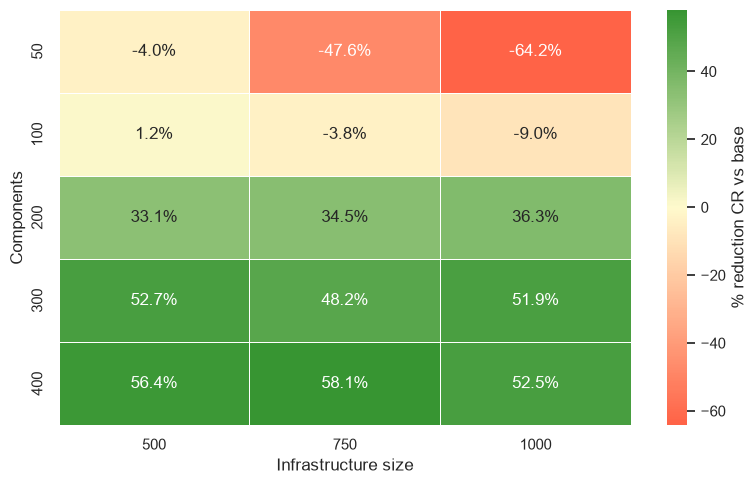

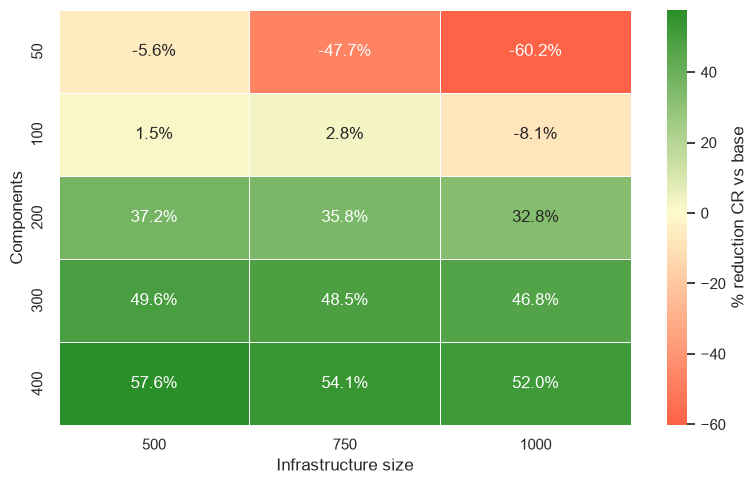

In [27]:
base_mode = "base"
cr_mode = "cr"

green_red_cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_green",
    ["tomato", "lemonchiffon", "forestgreen"]
)

def heatmap(plot_df: pd.DataFrame, metric: str, topology: str):
    data = plot_df[
        (plot_df["callback_id"] == metric) &
        (plot_df["topology"] == topology) &
        (plot_df["mode"].isin([base_mode, cr_mode]))
    ].copy()

    data = data.groupby(outlier_group_cols).apply(remove_outliers_iqr).copy()

    agg = (
        data
        .groupby(["mode", "nodes", "components"], as_index=False)
        .agg(mean_value=("value", "mean"))
    )

    wide = agg.pivot_table(index=["nodes", "components"],columns="mode",values="mean_value").reset_index()

    wide["pct_distance"] = np.where(
        wide[base_mode] != 0,
        100 * (wide[base_mode] - wide[cr_mode]) / wide[base_mode],
        np.nan
    )

    heatmap_data = wide.pivot(index="components",columns="nodes",values="pct_distance")
    
    annot_data = heatmap_data.map(lambda x: "" if pd.isna(x) else f"{x:.1f}%"    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        heatmap_data,
        annot=annot_data,
        fmt = "",
        cmap=green_red_cmap,
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "% reduction CR vs base"}
    )

    # plt.title(f"{METRIC_LABELS[metric]} - {topology}\n")
    plt.xlabel(COL_LABELS["nodes"])
    plt.ylabel(COL_LABELS["components"])

    plt.tight_layout()
    fig_path = HEATMAP_PLOTS_PATH / metric / topology
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path.with_suffix(f".{FIG_FORMAT}"), dpi=FIG_DPI)
    plt.show()

for topology in TOPOLOGIES:
    heatmap(plot_df, METRICS[0], topology)

## SCATTERPLOT

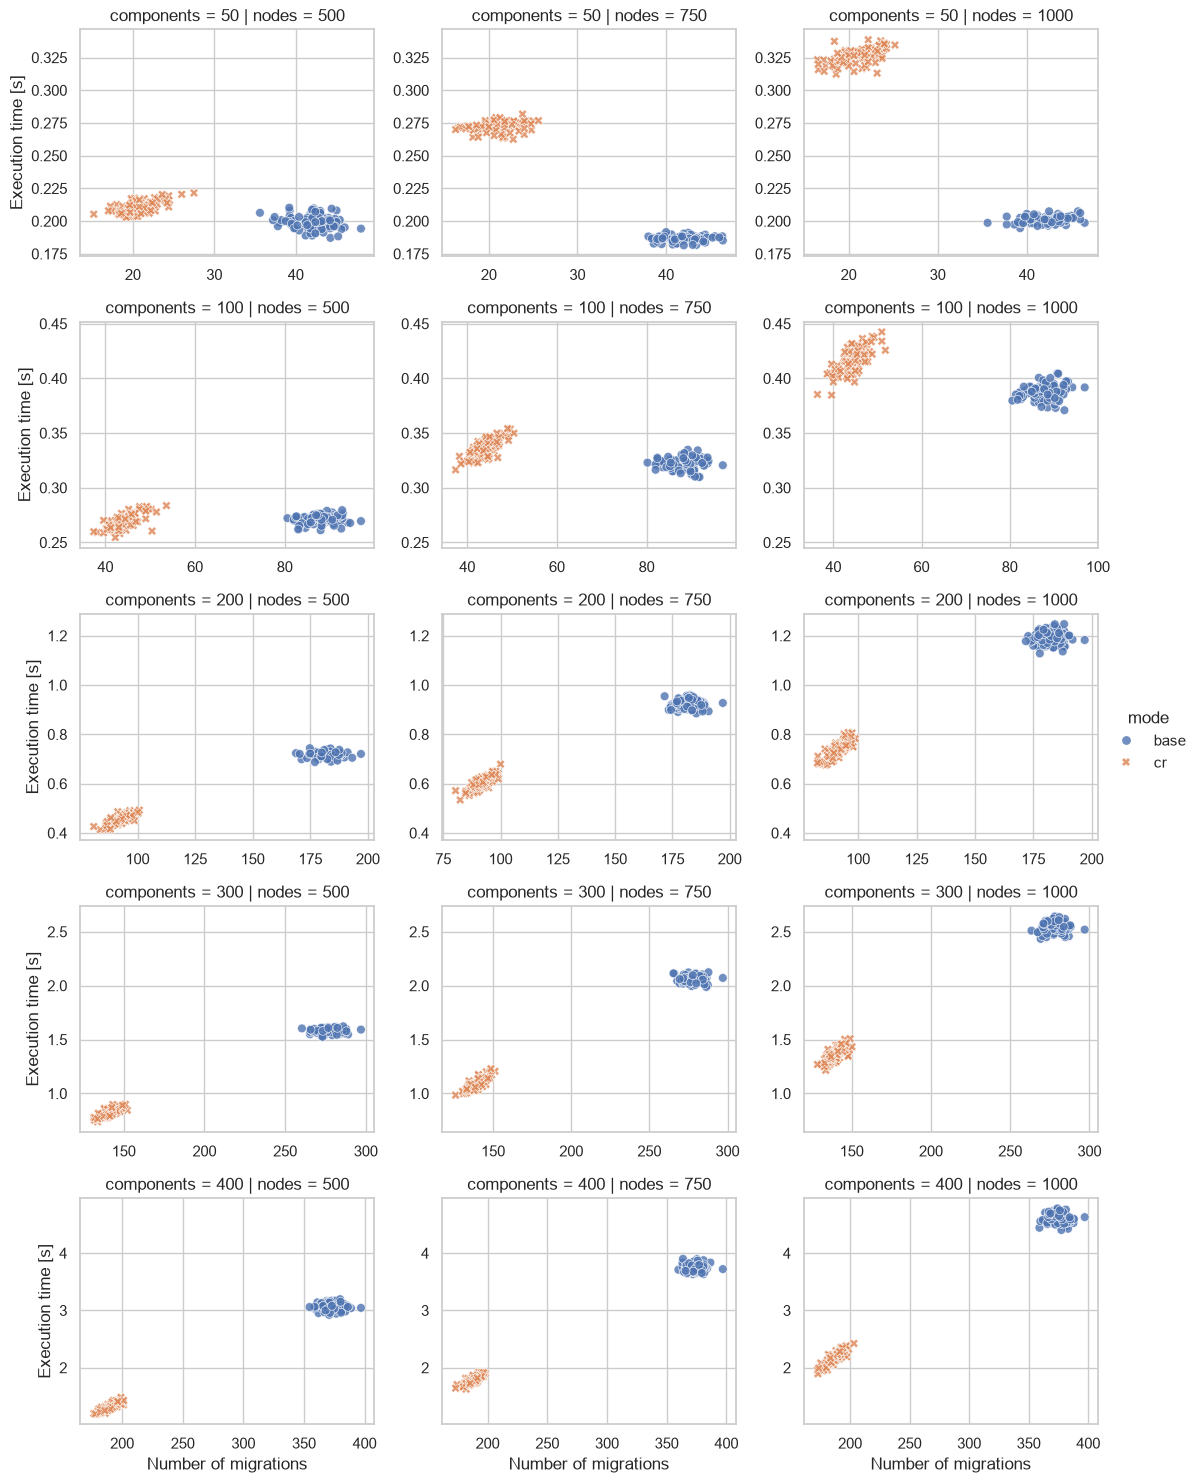

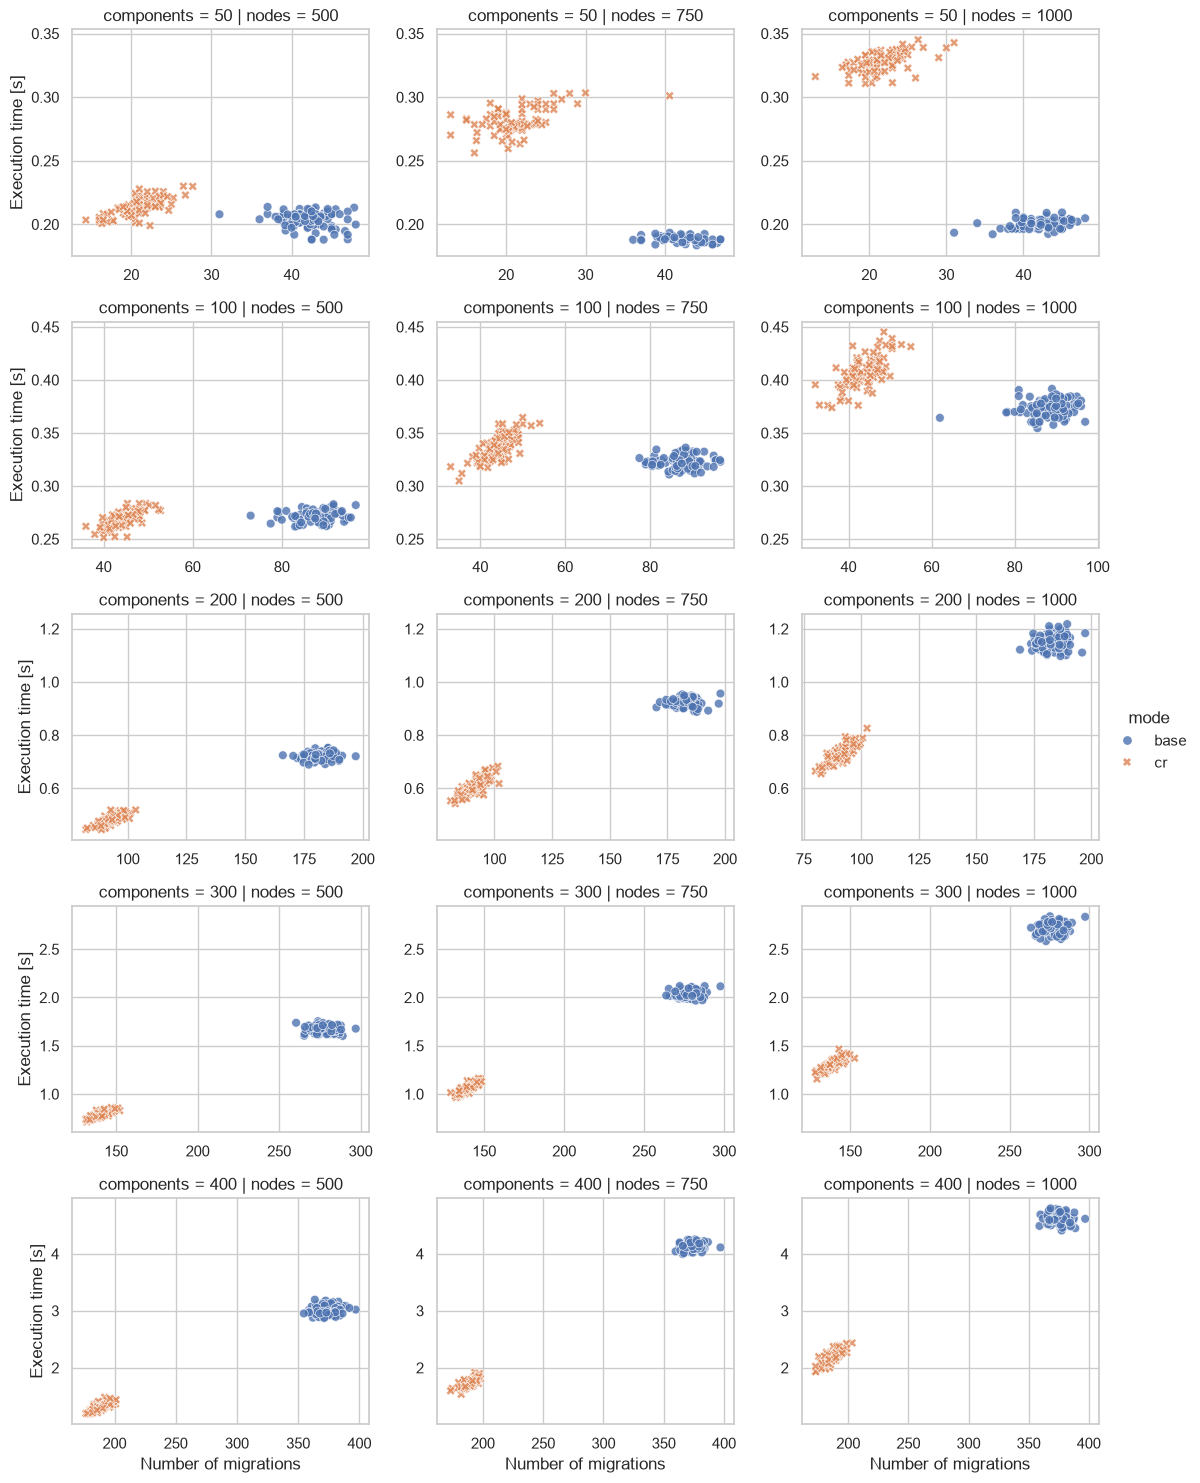

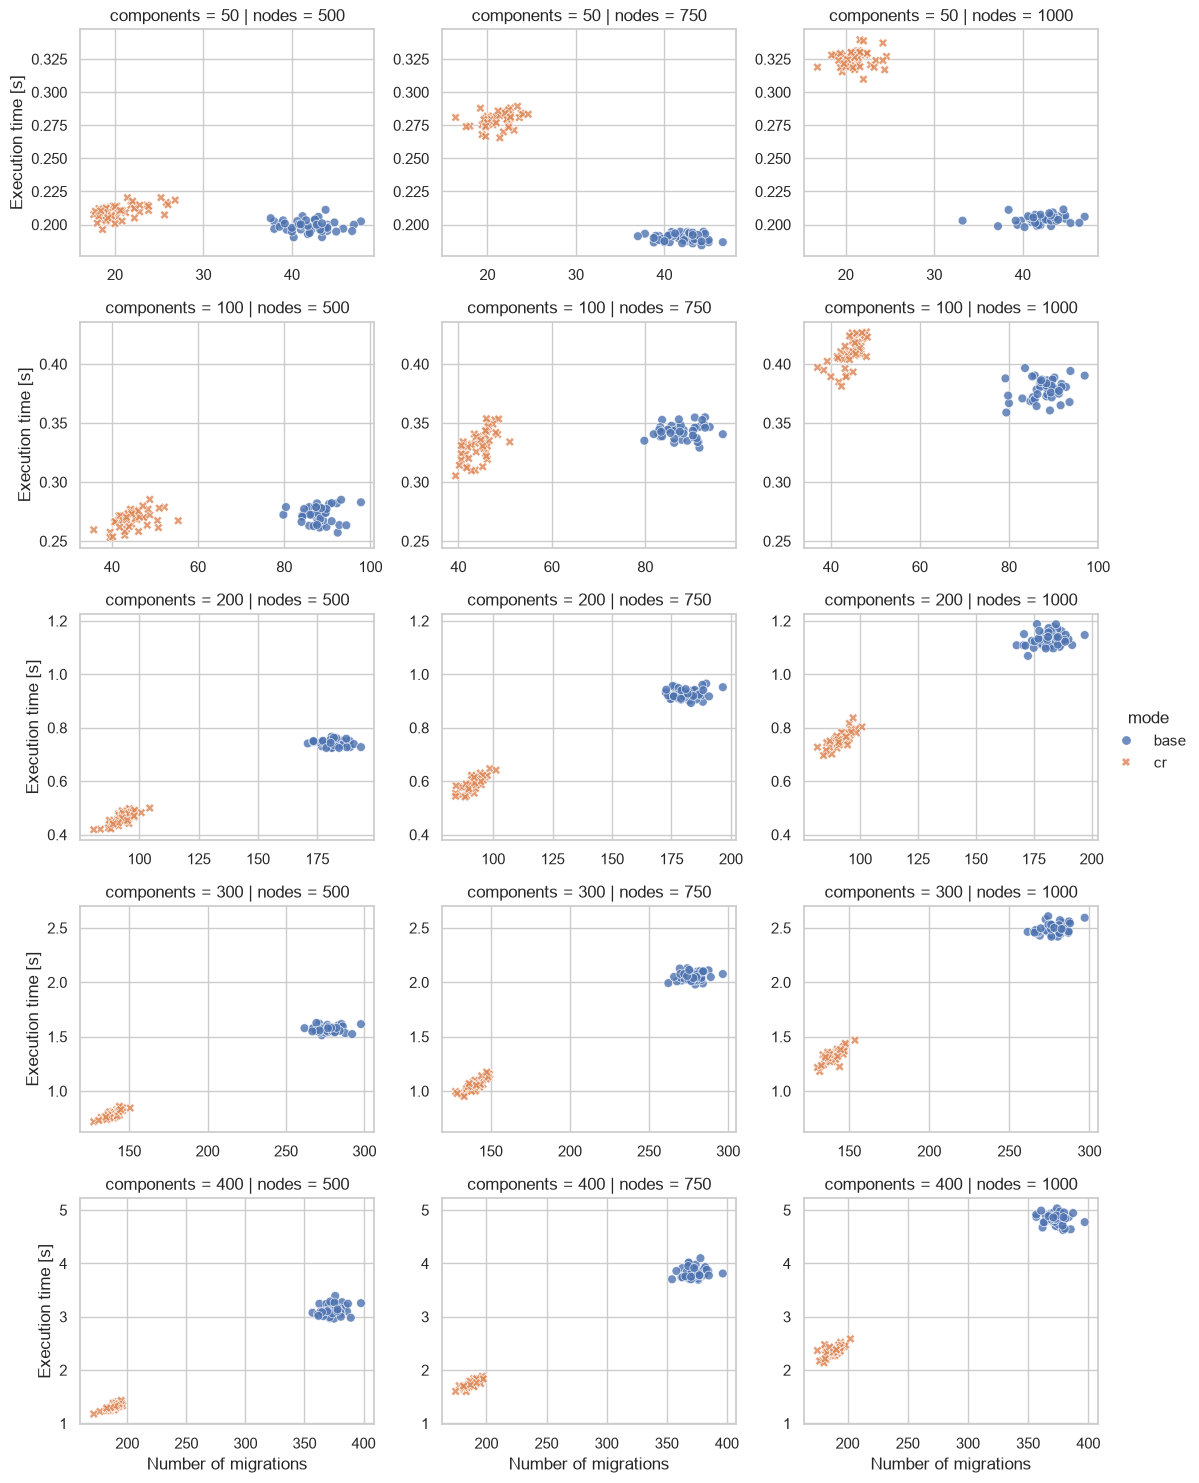

In [28]:
migration_metric = "placement_migrations"
execution_metric = "prolog_query_seconds"

id_cols = ["mode", "nodes", "components", "topology", "n_event"]
out_cols = ["mode", "nodes", "components", "topology"]

def plot_migrations_vs_execution_relplot(
    plot_df: pd.DataFrame,
    migration_metric: str,
    execution_metric: str,
    topology: str,
) -> None:

    data = plot_df[
        (plot_df["topology"] == topology) &
        (plot_df["callback_id"].isin([migration_metric, execution_metric]))
    ].copy()

    if data.empty:
        print(f"No data for topology={topology}")
        return

    wide = (
        data
        .pivot_table(
            index=id_cols,
            columns="callback_id",
            values="value",
            aggfunc="mean"
        )
        .reset_index()
    )

    wide.columns.name = None

    wide = wide.rename(columns={
        migration_metric: "n_migrations",
        execution_metric: "execution_time"
    })

    wide = wide.dropna(subset=["n_migrations", "execution_time"])

    if wide.empty:
        print(f"No paired data for topology={topology}")
        return

    grouped = wide.groupby(out_cols)["execution_time"]

    q1 = grouped.transform(lambda s: s.quantile(0.25))
    q3 = grouped.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    keep = (
        iqr.isna() |
        (iqr == 0) |
        wide["execution_time"].between(lower, upper)
    )

    wide = wide[keep].copy()

    if wide.empty:
        print(f"No data after outlier removal for topology={topology}")
        return

    nodes_order = sorted(wide["nodes"].dropna().unique())
    components_order = sorted(wide["components"].dropna().unique())

    g = sns.relplot(
        data=wide,
        x="n_migrations",
        y="execution_time",
        hue="mode",
        style="mode",
        col="nodes",
        row="components",
        col_order=nodes_order,
        row_order=components_order,
        kind="scatter",
        s=40,
        alpha=0.8,
        height=3.0,
        aspect=1.25,
        facet_kws={
            "sharex": False,
            "sharey": False,
        },
    )

    g.set_axis_labels("Number of migrations", "Execution time [s]")
    g.set_titles(
        row_template="components = {row_name}",
        col_template="nodes = {col_name}"
    )

    # Stessa scala Y per tutti i grafici della stessa riga
    for row_idx, component in enumerate(components_order):
        row_data = wide[wide["components"] == component]

        if row_data.empty:
            continue

        y_min = row_data["execution_time"].min()
        y_max = row_data["execution_time"].max()

        if pd.isna(y_min) or pd.isna(y_max):
            continue

        if y_min == y_max:
            padding = 0.05 * abs(y_max) if y_max != 0 else 1
        else:
            padding = 0.05 * (y_max - y_min)

        for ax in g.axes[row_idx, :]:
            ax.set_ylim(y_min - padding, y_max + padding)

    # Limite X per singolo grafico:
    # xmax = ceil(max n_migrations del singolo subplot)
    for row_idx in range(len(components_order)):
        for col_idx in range(len(nodes_order)):
            ax = g.axes[row_idx, col_idx]
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)

    # g.figure.suptitle(
    #     f"topology={topology}",
    #     y=1.03,
    #     fontsize=14
    # )

    for ax in g.axes.flat:
        ax.grid(True)

    fig_path = SCATTERPLOT_PLOTS_PATH / topology
    fig_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        fig_path.with_suffix(f".{FIG_FORMAT}"),
        dpi=FIG_DPI,
        format=FIG_FORMAT,
        bbox_inches="tight"
    )

    plt.show()


for topology in TOPOLOGIES:
    plot_migrations_vs_execution_relplot(
        plot_df=plot_df,
        migration_metric=migration_metric,
        execution_metric=execution_metric,
        topology=topology,
    )